In [1]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 16.38it/s]


Numba compilation complete!


In [2]:
#initial file processing
workcomp = "C:\\Users\\User"
computer2 = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
titledpath = homecomp
openPath = titledpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "ACR"
respondercsv = responder + ".csv"
wt = "w1118"


In [3]:
lstnew=[]


for file_no in os.listdir(openPath): 
    if respondercsv in file_no and "w1118" not in file_no :   #wt > acr files
        f = os.path.join(openPath, file_no)
        dfe=pd.read_csv(f)
        exptdf = dfe.drop(dfe.columns[[0]],axis = 1)
        driver = file_no.split(" ")[0]
        lstnew.append(driver)

In [45]:
newfile2 = openPath + "Compilation with delta\\2025meandiffcollection\\"
interestline = "SS67662 x Chrimson2"
metricname = pd.DataFrame()
singlemeandiff= pd.DataFrame()

files2 = os.listdir(newfile2)
newfile2read = pd.read_csv(newfile2 + interestline + " allstats.csv")
nameofmbon = interestline.split(" ")[0]

#all variables
lstofallvariables = []
for j in newfile2read.columns.to_list()[1:]:
    lstofallvariables.append(j.split("_")[0])
lstnamings= sorted(list(set(lstofallvariables)))

#only if specific variables
metriclst = ['bspeed', 'speed' , 'height', 'straightindex', 'meanpause', 'pause', 'fallnumber', 'fallprop']
lstnamings = metriclst.copy() 

samplefile = pd.DataFrame()
singlemeans = pd.DataFrame()

for k in lstnamings:
    samplefile['bootstrap'] = newfile2read[k+"_bootstrap"]
    samplefile['deltag'] = newfile2read[k+"_deltag"]
    samplefile["metric"] = k
    samplefile['MBON'] = nameofmbon
    
    singlemeans['mean'] = samplefile['deltag'].unique()
    singlemeans['metric'] = k
    singlemeans['err'] =  samplefile['bootstrap'].mean() - (samplefile['bootstrap'].mean() - 1.96*(np.std(samplefile['bootstrap'])))  #mean -bca_low (self calculated)
    
    metricname = pd.concat([metricname, samplefile], axis=0)
    singlemeandiff = pd.concat([singlemeandiff, singlemeans], axis=0)
singlemeandiff = singlemeandiff.replace("bspeed", "boutspeed").replace("meanpause", "mean pause duration").replace("pause", "pause #").replace("fallnumber", "fall #")

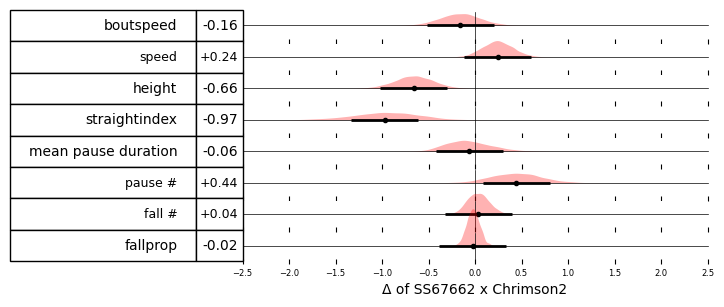

In [46]:
# in the sns.FacetGrid class, the 'hue' argument is the one that is the one that will be represented by colors with 'palette'
g = sns.FacetGrid(metricname, row='metric', aspect = 15,
                 height=0.4)

if "Chrimson2" in interestline:
      color  = "r"
else:
      color = "g"
      
g.map(sns.kdeplot, 'bootstrap', color= color,
      bw_adjust=1, clip_on=False, clip = (-2,2),
      fill=True, alpha=0.3, linewidth=0, warn_singular=False)

g.map(plt.axhline, y=0, color="k",
      lw=0.5, clip_on=False)

g.map(plt.axvline, x=0,
      lw=0.5, clip_on=False, color="k")

#for mean line and dots
for ax, mean, err, cat in zip(g.axes.flat, 
                              singlemeandiff["mean"], 
                              singlemeandiff['err'],
                              singlemeandiff['metric']):
    ax.errorbar(x=mean, y=0, xerr = 0.36, fmt='o',
                ecolor="k", elinewidth = 2,
            **{"mfc" : "k", "mec" : "k", "markersize" : 3})
    ax.set_ylim(-2,2)  #height of bar
    cell_text = cat.split(",")
    cell_text.append("{:+.2f}".format(mean))
    table = ax.table(cellText=[cell_text],loc="left")
    cellDict = table.get_celld()
    for i in range(0,2):
        cellDict[(0,i)].set_height(1.2)
        cellDict[(0,0)].set_width(0.4)
        cellDict[(0,1)].set_width(0.1)


g.set_titles("")
g.set(yticks=[])

plt.xticks(np.arange(-2.5, 3.0, 0.5).tolist(), fontsize = 6)
g.set_ylabels("")
g.set_xlabels("Δ of " + interestline )
g.despine(bottom=True, left=True)

#g.savefig("full_light_forest_plot.pdf", dpi=300, bbox_inches="tight")